,type,regime,mean_pre,mean_net,mean_tax,mean_ATR,ATR_p10,ATR_p50,ATR_p90,MTR_p10,MTR_p50,MTR_p90
0,0,Linear,0.289418,0.231534,0.057884,0.200000,0.200000,0.200000,0.200000,NaN,NaN,NaN
1,0,No tax,0.289418,0.289418,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
2,0,Nonlinear (isoelastic),0.289418,0.358840,-0.069422,-0.346208,-0.573225,-0.335206,-0.133137,-0.258580,-0.068165,0.093490
3,1,Linear,0.532128,0.425702,0.106426,0.200000,0.200000,0.200000,0.200000,NaN,NaN,NaN
4,1,No tax,0.532128,0.532128,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
5,1,Nonlinear (isoelastic),0.532128,0.584277,-0.052149,-0.191457,-0.392211,-0.181874,-0.003103,-0.113769,0.054501,0.197518
6,2,Linear,1.068376,0.854701,0.213675,0.200000,0.200000,0.200000,0.200000,NaN,NaN,NaN
7,2,No tax,1.068376,1.068376,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN
8,2,Nonlinear (isoelastic),1.068376,1.020275,0.048101,-0.036567,-0.211195,-0.027963,0.126641,0.031044,0.177629,0.301313



=== Nonlinear regime: average tax rate (ATR) quantiles (overall) ===


,income_quantile,income_level,ATR_at_quantile
0,0.01,0.070880,-0.697833
1,0.10,0.152714,-0.456211
2,0.25,0.243127,-0.326885
3,0.50,0.412903,-0.193522
4,0.75,0.708505,-0.071350
5,0.90,1.152070,0.027915
6,0.99,2.599465,0.173918


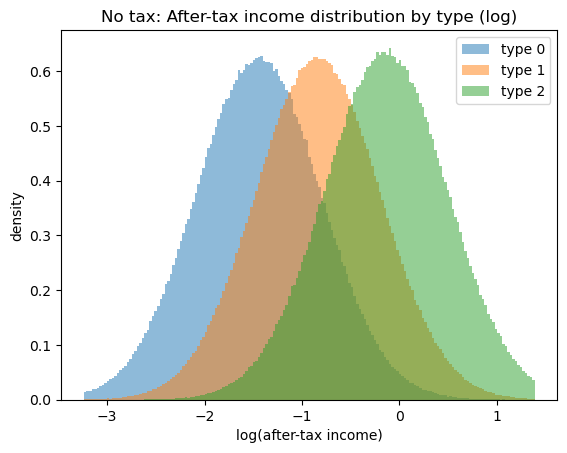

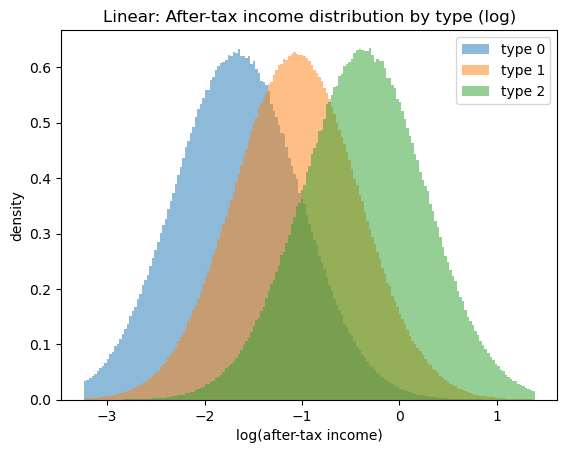

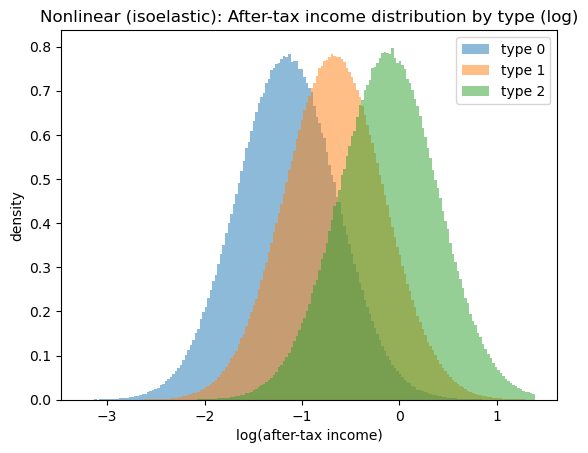

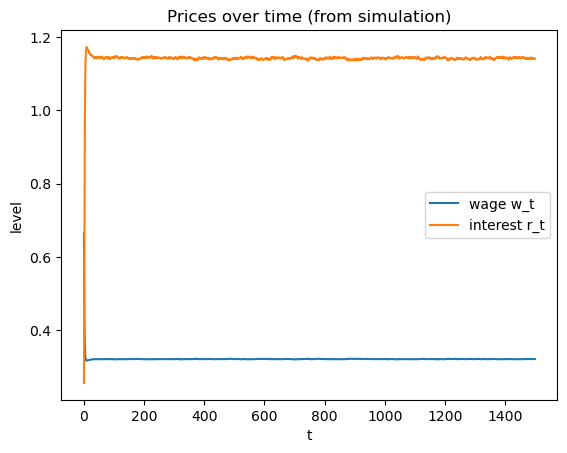


Notes:
- In the nonlinear isoelastic tax, there is NO bracket threshold ybar.
- 'Triggering' shows up as ATR/MTR varying with income. Check the ATR/MTR columns above.
- If ATR/MTR barely varies, try increasing xi_nl (e.g., 0.3~0.6) or widening income dispersion (eta_type, sigma).


In [3]:
# Colab SINGLE CELL: simulate pre-tax income (production + AR(1) + 3 types),
# then plot AFTER-TAX income distributions by type under:
#   1) No tax
#   2) Linear tax
#   3) Nonlinear tax:  T(i) = i - (1-τ) * i^(1-ξ) / (1-ξ)   (and the ξ→1 log limit)
# Goal: verify numerically that income levels generate visible tax-rate differences.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# 0) Parameters (edit here)
# -----------------------
N = 30_000
T = 1_500
burn = 700
keep_last = 200
seed = 0

# Cobb–Douglas production
A = 1.0
alpha = 0.36
delta = 0.08

# Idiosyncratic process: z_{t+1} = rho z_t + sigma eps
rho = 0.95
sigma = 0.20

# 3 types: permanent component eta_type
type_probs = (0.3, 0.5, 0.2)
eta_type = (-0.4, 0.0, 0.35)

# Initial assets distribution (positive)
a0_loc = -0.2
a0_scale = 0.7

# Simple rule-based policy (replace with your NN policy later)
zeta_base = (0.15, 0.22, 0.30)  # type-specific saving-share baseline
zeta_slope = 0.05              # response to log(m_proxy)
h_base = (0.90, 0.95, 1.00)    # type-specific labor supply baseline

# Tax: linear
tau_linear = 0.20              # T(y) = tau * y

# Tax: nonlinear isoelastic (your formula)
tau_nl = 0.20                  # τ in the formula
xi_nl  = 0.20                  # ξ in the formula (0 => linear; ξ close to 1 => log limit)

# -----------------------
# 1) Helper functions
# -----------------------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def simulate_pre_tax_income_draws():
    """
    Forward simulation:
      production -> (w,r) -> pre-tax income -> money-on-hand -> next assets
    Returns:
      pre-tax income draws (last keep_last periods after burn-in), separated by type
    """
    rng = np.random.default_rng(seed)
    eps = 1e-12

    types = rng.choice(3, size=N, p=np.array(type_probs))
    eta = np.array(eta_type)[types]

    z = np.zeros(N)
    v = np.exp(eta + z)

    a = np.exp(rng.normal(a0_loc, a0_scale, size=N))  # positive assets
    zb = np.array(zeta_base)[types]
    hb = np.array(h_base)[types]

    income_draws_by_type = {0: [], 1: [], 2: []}
    agg_rows = []

    for t in range(T):
        # --- policy (rule-based; replace with your NN policy if needed) ---
        h = np.clip(hb, 0.0, 1.0)
        m_proxy = np.maximum(a, eps)
        logit_base = np.log(np.maximum(zb, eps) / np.maximum(1 - zb, eps))
        zeta = sigmoid(logit_base + zeta_slope * np.log(m_proxy))
        zeta = np.clip(zeta, 0.01, 0.99)

        # --- aggregates & prices ---
        N_eff = np.sum(v * h)
        K = np.sum(a)
        N_eff = max(N_eff, eps)
        K = max(K, eps)

        KN = K / N_eff
        w = (1 - alpha) * A * (KN ** alpha)
        r = alpha * A * (KN ** (alpha - 1)) - delta

        # --- pre-tax income ---
        i = w * v * h + r * a

        # --- money-on-hand (no tax here; we apply taxes later to the same pre-tax draws) ---
        m = np.maximum(i + a, eps)
        a_next = np.maximum(zeta * m, eps)

        agg_rows.append(dict(t=t, K=K, N_eff=N_eff, w=w, r=r, mean_income=float(np.mean(i))))

        # store last keep_last periods after burn-in
        if t >= burn and t >= (T - keep_last):
            for k in (0, 1, 2):
                income_draws_by_type[k].append(i[types == k].copy())

        # evolve idiosyncratic process
        z = rho * z + sigma * rng.standard_normal(N)
        v = np.exp(eta + z)
        a = a_next

    income_by_type = {k: (np.concatenate(vv, axis=0) if vv else np.array([]))
                      for k, vv in income_draws_by_type.items()}
    agg_df = pd.DataFrame(agg_rows)
    return income_by_type, agg_df

def after_tax_none(y):
    return y.copy()

def after_tax_linear(y, tau):
    # Apply tax only when y > 0
    y = np.asarray(y)
    ynet = y.copy()
    pos = y > 0
    ynet[pos] = (1 - tau) * y[pos]
    return ynet

def after_tax_isoelastic(y, tau, xi):
    """
    Your tax setting:
      T(y) = y - (1-τ) * y^(1-ξ) / (1-ξ)
    => after-tax income:
      y_net = (1-τ) * y^(1-ξ) / (1-ξ),  for ξ != 1
      y_net = (1-τ) * log(y),           for ξ == 1 (limit)
    We apply it only for y > 0. For y <= 0, we leave y unchanged (no tax).
    """
    y = np.asarray(y)
    ynet = y.copy()
    pos = y > 0
    eps = 1e-12
    y_pos = np.maximum(y[pos], eps)

    if abs(1.0 - xi) > 1e-10:
        ynet[pos] = (1 - tau) * (y_pos ** (1 - xi)) / (1 - xi)
    else:
        ynet[pos] = (1 - tau) * np.log(y_pos)

    return ynet

def tax_payment(y, ynet):
    # Tax is defined as y - ynet
    return y - ynet

def effective_tax_rate(y, tax):
    # Average tax rate: tax / y for y>0, else 0
    y = np.asarray(y)
    tax = np.asarray(tax)
    out = np.zeros_like(y, dtype=float)
    pos = y > 0
    out[pos] = tax[pos] / y[pos]
    return out

def marginal_tax_rate_isoelastic(y, tau, xi):
    """
    For ξ != 1:
      y_net = (1-τ) * y^(1-ξ)/(1-ξ)
      dy_net/dy = (1-τ) * y^(-ξ)
      MTR = 1 - dy_net/dy = 1 - (1-τ) * y^(-ξ)
    For ξ == 1:
      y_net = (1-τ) * log(y)
      dy_net/dy = (1-τ)/y
      MTR = 1 - (1-τ)/y
    """
    y = np.asarray(y)
    out = np.zeros_like(y, dtype=float)
    pos = y > 0
    eps = 1e-12
    y_pos = np.maximum(y[pos], eps)

    if abs(1.0 - xi) > 1e-10:
        out[pos] = 1.0 - (1.0 - tau) * (y_pos ** (-xi))
    else:
        out[pos] = 1.0 - (1.0 - tau) / y_pos

    return out

def summarize(pre_by_type, regimes):
    rows = []
    for k in (0, 1, 2):
        y = pre_by_type[k]
        if y.size == 0:
            continue
        for name, ynet_fn in regimes.items():
            ynet = ynet_fn(y)
            tax = tax_payment(y, ynet)
            atr = effective_tax_rate(y, tax)

            # For the nonlinear regime, also report MTR quantiles as a "trigger" diagnostic
            if name == "Nonlinear (isoelastic)":
                mtr = marginal_tax_rate_isoelastic(y, tau_nl, xi_nl)
                mtr_p10 = float(np.quantile(mtr[y > 0], 0.10)) if np.any(y > 0) else np.nan
                mtr_p50 = float(np.quantile(mtr[y > 0], 0.50)) if np.any(y > 0) else np.nan
                mtr_p90 = float(np.quantile(mtr[y > 0], 0.90)) if np.any(y > 0) else np.nan
            else:
                mtr_p10 = mtr_p50 = mtr_p90 = np.nan

            rows.append(dict(
                type=k,
                regime=name,
                mean_pre=float(np.mean(y)),
                mean_net=float(np.mean(ynet)),
                mean_tax=float(np.mean(tax)),
                mean_ATR=float(np.mean(atr)),
                ATR_p10=float(np.quantile(atr[y > 0], 0.10)) if np.any(y > 0) else np.nan,
                ATR_p50=float(np.quantile(atr[y > 0], 0.50)) if np.any(y > 0) else np.nan,
                ATR_p90=float(np.quantile(atr[y > 0], 0.90)) if np.any(y > 0) else np.nan,
                MTR_p10=mtr_p10, MTR_p50=mtr_p50, MTR_p90=mtr_p90,
            ))
    return pd.DataFrame(rows)

# -----------------------
# 2) Simulate pre-tax draws once
# -----------------------
pre_income_by_type, agg_df = simulate_pre_tax_income_draws()

# Define regimes (apply to the SAME pre-tax draws for a clean diagnostic)
regimes = {
    "No tax": lambda y: after_tax_none(y),
    "Linear": lambda y: after_tax_linear(y, tau_linear),
    "Nonlinear (isoelastic)": lambda y: after_tax_isoelastic(y, tau_nl, xi_nl),
}

# -----------------------
# 3) Numeric diagnostics (does nonlinear actually create varying tax rates?)
# -----------------------
summary_df = summarize(pre_income_by_type, regimes)
display(summary_df.sort_values(["type", "regime"]).reset_index(drop=True))

# Extra: show how ATR varies with income quantiles for the nonlinear regime (overall)
all_pre = np.concatenate([pre_income_by_type[k] for k in (0, 1, 2) if pre_income_by_type[k].size > 0])
all_net_nl = after_tax_isoelastic(all_pre, tau_nl, xi_nl)
all_tax_nl = tax_payment(all_pre, all_net_nl)
all_atr_nl = effective_tax_rate(all_pre, all_tax_nl)

q_grid = np.array([0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
atr_by_q = pd.DataFrame({
    "income_quantile": q_grid,
    "income_level": [float(np.quantile(all_pre[all_pre > 0], q)) for q in q_grid],
    "ATR_at_quantile": [float(np.quantile(all_atr_nl[all_pre > 0], q)) for q in q_grid],
})
print("\n=== Nonlinear regime: average tax rate (ATR) quantiles (overall) ===")
display(atr_by_q)

# -----------------------
# 4) Plots: AFTER-TAX income distributions by type (log scale), for each regime
# -----------------------
eps = 1e-12

# Use consistent bins in log space for comparability
all_net_log = []
for k in (0, 1, 2):
    y = pre_income_by_type[k]
    if y.size == 0:
        continue
    for _, ynet_fn in regimes.items():
        ynet = np.maximum(ynet_fn(y), eps)
        all_net_log.append(np.log(ynet))
all_net_log = np.concatenate(all_net_log, axis=0)

log_min, log_max = np.quantile(all_net_log, 0.001), np.quantile(all_net_log, 0.999)
bins = np.linspace(log_min, log_max, 180)

for regime_name, ynet_fn in regimes.items():
    plt.figure()
    for k in (0, 1, 2):
        y = pre_income_by_type[k]
        if y.size == 0:
            continue
        ynet = np.maximum(ynet_fn(y), eps)
        plt.hist(np.log(ynet), bins=bins, density=True, alpha=0.5, label=f"type {k}")
    plt.title(f"{regime_name}: After-tax income distribution by type (log)")
    plt.xlabel("log(after-tax income)")
    plt.ylabel("density")
    plt.legend()
    plt.show()

# Optional: show prices over time (sanity check)
plt.figure()
plt.plot(agg_df["t"], agg_df["w"], label="wage w_t")
plt.plot(agg_df["t"], agg_df["r"], label="interest r_t")
plt.title("Prices over time (from simulation)")
plt.xlabel("t")
plt.ylabel("level")
plt.legend()
plt.show()

print("\nNotes:")
print("- In the nonlinear isoelastic tax, there is NO bracket threshold ybar.")
print("- 'Triggering' shows up as ATR/MTR varying with income. Check the ATR/MTR columns above.")
print("- If ATR/MTR barely varies, try increasing xi_nl (e.g., 0.3~0.6) or widening income dispersion (eta_type, sigma).")